# Descripción de proyecto

Trabajas como analista de datos para la empresa de telecomunicaciones Megaline, la cual ofrece a sus clientes dos planes de prepago: Surf y Ultimate. El departamento comercial necesita identificar cuál de estos planes genera mayores ingresos, con el fin de optimizar la asignación del presupuesto de publicidad.

Para apoyar esta decisión, se realizará un análisis preliminar de las tarifas utilizando una muestra de clientes. El conjunto de datos incluye información de 500 usuarios de Megaline, como su ubicación, el plan que utilizan y sus patrones de consumo durante el año 2018, incluyendo la cantidad de llamadas realizadas, mensajes de texto enviados y uso de datos móviles.

Además de estimar los ingresos generados por cada plan, el análisis también se enfocará en comprender el comportamiento de los clientes, identificando patrones de uso y diferencias en el consumo entre los usuarios de cada tarifa.

El objetivo principal de este análisis es evaluar cómo se comportan los clientes según el plan contratado y determinar cuál de los planes de prepago genera mayores ingresos en promedio. Esta diferencia en ingresos será evaluada posteriormente mediante pruebas estadísticas.

# Descripción de las tarifas
Nota: Megaline redondea los segundos a minutos y los megabytes a gigabytes. Para las llamadas, cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto. Para el tráfico web, las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.

A continuación puedes ver una descripción de las tarifas:
    
Surf

Pago mensual: $20.00\
500 minutos al mes, 50 SMS y 15 GB de datos\
Si se exceden los límites del paquete:\
1 minuto: 3 centavos\
1 SMS: 3 centavos\
1 GB de datos: $10.\
Ultimate

Pago mensual: $70.\
3000 minutos al mes, 1000 SMS y 30 GB de datos.\
Si se exceden los límites del paquete:\
1 minuto: 1 centavo\
1 SMS: 1 centavo\
1 GB de datos: $7.00

### Análisis general de los datos
1- Obtener todas las bases de datos y librerías necesarias

2- Visualizar el tipo de datos que se van a manejar

3- Visualizar posibles duplicados 

4- Corregir datos

5- Enriquecer los datos

In [34]:
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
# -----------------------------------------------------------------------#
meg_calls = pd.read_csv('datasets/megaline_calls.csv')
meg_internet = pd.read_csv('datasets/megaline_internet.csv')
meg_msm = pd.read_csv('datasets/megaline_messages.csv')
meg_plans = pd.read_csv('datasets/megaline_plans.csv')
meg_users = pd.read_csv('datasets/megaline_users.csv')

In [35]:
meg_calls.info()
meg_calls.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
24909,1097_12,1097,2018-12-04,4.42
50129,1181_437,1181,2018-06-12,14.12
3461,1011_314,1011,2018-12-29,0.00
23213,1085_5,1085,2018-09-30,0.00
126307,1447_172,1447,2018-12-05,6.27
83373,1302_147,1302,2018-11-29,6.13
50661,1183_5,1183,2018-11-30,6.14
71076,1252_561,1252,2018-07-16,8.78
70628,1251_639,1251,2018-08-07,9.93
5110,1022_376,1022,2018-08-15,7.77


In [36]:
meg_internet.info()
meg_internet.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
78785,1367_416,1367,2018-10-27,0.00
1824,1009_359,1009,2018-09-10,279.47
65217,1300_103,1300,2018-10-27,176.69
29414,1134_198,1134,2018-12-22,578.47
39500,1177_244,1177,2018-12-29,93.59
67949,1316_218,1316,2018-06-20,284.47
9028,1046_313,1046,2018-09-21,0.00
76201,1358_387,1358,2018-09-25,379.77
883,1004_582,1004,2018-09-05,734.79
96300,1451_45,1451,2018-09-26,558.27


In [37]:
meg_msm.info()
meg_msm.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
64366,1409_121,1409,2018-10-22
51418,1335_6,1335,2018-07-18
25004,1147_206,1147,2018-07-28
74721,1483_55,1483,2018-07-15
25589,1154_172,1154,2018-10-02
6804,1057_128,1057,2018-10-26
25820,1155_195,1155,2018-03-27
53415,1339_549,1339,2018-09-23
75618,1491_545,1491,2018-07-09
63370,1404_41,1404,2018-11-24


In [38]:
meg_plans.info()
meg_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [39]:
meg_users.info()
meg_users.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
159,1159,Dierdre,Baker,58,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-07-21,ultimate,NaN
192,1192,Korey,Goodwin,36,"Buffalo-Cheektowaga, NY MSA",2018-10-02,surf,NaN
146,1146,Loma,Mcneil,42,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-10-13,surf,NaN
105,1105,Micheal,Poole,57,"Providence-Warwick, RI-MA MSA",2018-01-08,surf,NaN
221,1221,Mckenzie,Wilkinson,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-12-17,surf,NaN


Todos estos datasets tienen distintos propositos, como los 3 primeros que tiene informacion acerca del consumo de cada servicio proporcionado, uno para internet, otro para mensajes y etc.
Uno con infomacion acerca de los usuarios y otro acerca de los datos de las tarifas que ofrece esta empresa.

Se puede ver que en todos los datasets el tipo de dato para las fechas es incorrecto.

La columna de datos "Churn date" contiene informacion sobre la cancelacion de susbcripcion y tiene valores vacios que se puede interpretar como que el usuario no ha cancelado su membresia asi que esta columna puede ir asi

En la base de datos meg_plans, los nombres de las columnas son demasiado largas, esto se puede reducir.

aqui se vio algo interesante y es que en varias ocaciones aparece el comsumo de internet en 0 o llamadas con duracion de 0, esto puede significar dos cosas que se estan tomando todos los dias sin excepcion o que se recopilo esta informacion por error

Y en el apartado de internet la unidad de medida presentada es en gigabite y en las distitnas tablas se presenta como megabite, lo cual puede volver el proceso de analisis engorroso por lo que se tiene que transormar para tener un mejor seguimiento

# Comprobacion de informacion

In [40]:
comprobacion = meg_internet.sort_values(
    by=['user_id', 'session_date'], ascending=True)
usuario = np.random.choice(meg_users['user_id'])
print(comprobacion[(comprobacion)['user_id'] == usuario])

             id  user_id session_date  mb_used
19772    1090_2     1090   2018-05-13   288.69
19837   1090_68     1090   2018-05-14   461.62
19950  1090_183     1090   2018-05-14   367.45
19853   1090_84     1090   2018-05-15   189.86
19863   1090_95     1090   2018-05-15   182.42
...         ...      ...          ...      ...
19865   1090_97     1090   2018-12-28     3.42
19935  1090_168     1090   2018-12-28    33.80
20165  1090_406     1090   2018-12-28   604.45
19872  1090_104     1090   2018-12-30   603.21
20085  1090_323     1090   2018-12-30   267.36

[414 rows x 4 columns]


Aqui lo que se hizo es agarrar a un usuario al alzar y mostrar todo su historial de consumo, y demostro que incluso en un mismo dia hay registros con 0 de consumo lo cual se puede explicar si un usuario inicio sesion pero no descargo nada... pasara lo mismo con las llamadas?

In [41]:
comprobacion = meg_calls.sort_values(
    by=['user_id', 'call_date'], ascending=True)
usuario = np.random.choice(meg_users['user_id'])
print(comprobacion[(comprobacion)['user_id'] == usuario])

             id  user_id   call_date  duration
84163   1308_39     1308  2018-11-23      6.81
84190   1308_78     1308  2018-11-23      0.00
84154   1308_27     1308  2018-11-25     16.90
84185   1308_71     1308  2018-11-26      0.00
84157   1308_30     1308  2018-11-27     15.65
...         ...      ...         ...       ...
84210  1308_112     1308  2018-12-29      7.31
84191   1308_81     1308  2018-12-30      0.00
84151   1308_21     1308  2018-12-31      0.28
84155   1308_28     1308  2018-12-31     15.98
84166   1308_45     1308  2018-12-31     11.88

[74 rows x 4 columns]


Demuestra el mismo comportamiento teniendo como explicacion que el conteo de llamdas se cuenta desde el momento que contesta la otra persona, los registros en 0 puede significar que esta llamada no fue contestada.

Dado que nuestro objetivo de investigacion se centra principalmente en analizar el consumo realizado y las ganancias generadas de cada plan esta informacion no es relevante, no se eliminara pero tampoco sera tomada en cuenta

asi que continuaremos a la correcion de los datos de los datasets presentados

# Correccion de errores en los datasets

In [42]:
# Cambio al tipo fecha de las columnas marcadas #

meg_users[['churn_date', 'reg_date']] = meg_users[[
    'churn_date', 'reg_date']].apply(pd.to_datetime)
meg_calls['call_date'] = pd.to_datetime(meg_calls['call_date'])
meg_internet['session_date'] = pd.to_datetime(meg_internet['session_date'])
meg_msm['message_date'] = pd.to_datetime(meg_msm['message_date'])


# Eliminar los datos duplicados #

meg_internet.drop_duplicates(inplace=True)
meg_calls.drop_duplicates(inplace=True)
meg_users.drop_duplicates(inplace=True)
meg_msm.drop_duplicates(inplace=True)

# Renombrar algunas columnas#

meg_plans = meg_plans.rename(columns={'plan_name': 'plan'})

In [43]:
meg_calls.info()
meg_calls.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
109923,1387_295,1387,2018-09-29,0.00
130102,1467_338,1467,2018-10-15,21.03
12952,1056_95,1056,2018-12-13,6.85
60757,1220_112,1220,2018-10-09,4.50
75595,1268_99,1268,2018-10-04,3.23
137703,1499_172,1499,2018-11-22,1.21
120202,1418_86,1418,2018-10-16,0.00
21731,1079_444,1079,2018-09-26,0.78
428,1003_38,1003,2018-12-18,3.38
32665,1123_23,1123,2018-12-28,10.34


In [44]:
meg_internet.info()
meg_internet.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
83812,1390_367,1390,2018-08-17,826.03
94815,1441_66,1441,2018-11-27,286.12
58529,1263_333,1263,2018-12-04,657.55
19572,1088_371,1088,2018-06-22,486.95
863,1004_557,1004,2018-12-14,643.87
82789,1387_5,1387,2018-10-05,336.38
13445,1062_415,1062,2018-11-23,129.93
9573,1049_223,1049,2018-11-27,409.94
48532,1216_27,1216,2018-10-16,654.09
74020,1347_115,1347,2018-11-14,0.00


In [45]:
meg_msm.info()
meg_msm.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


,id,user_id,message_date
30791,1193_568,1193,2018-12-24
7242,1059_114,1059,2018-10-20
55362,1348_84,1348,2018-10-25
53168,1339_302,1339,2018-12-27
57131,1362_202,1362,2018-10-18
38670,1254_202,1254,2018-11-15
6265,1055_383,1055,2018-06-14
55169,1347_206,1347,2018-08-06
40122,1259_166,1259,2018-04-06
42508,1279_41,1279,2018-11-09


In [46]:
meg_plans.info()
meg_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan                   2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [47]:
meg_users.info()
meg_users.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
439,1439,Moses,Cabrera,28,"Riverside-San Bernardino-Ontario, CA MSA",2018-01-04,surf,NaT
407,1407,Tristan,Daugherty,27,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-29,ultimate,NaT
200,1200,Delmar,Cross,45,"Boston-Cambridge-Newton, MA-NH MSA",2018-11-27,surf,NaT
357,1357,Ria,Beach,61,"Baton Rouge, LA MSA",2018-05-30,surf,NaT
157,1157,Luciano,Sheppard,63,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-07-02,surf,NaT


Con esto ademas de resolver las dudas de los valores en 0, tenemos los datsaets limpios por lo que podemos seguir con en analisis y en este caso con el enriquecimiento de los datos

# Enriquecimiento de datos

Se construirán datasets adicionales con el objetivo de organizar la información de manera más clara y facilitar el análisis, así como la generación de conclusiones sobre el comportamiento de los usuarios.

Para ello, se extrajo el componente mensual de las variables de fecha en los distintos datasets, con el fin de estandarizar la dimensión temporal y permitir una agregación consistente de la actividad por ciclo de facturación.

Asimismo, el límite de datos incluidos fue convertido de megabytes a gigabytes, aplicando redondeo hacia arriba (ceil). Esta transformación se realizó para alinearse con las reglas de facturación del negocio y garantizar precisión en el cálculo de ingresos y excedentes de consumo.

In [48]:
meg_msm["period"] = meg_msm["message_date"].dt.month
meg_calls["period"] = meg_calls["call_date"].dt.month
meg_users['month_reg'] = meg_users['reg_date'].dt.month
meg_users['month_churn'] = meg_users['churn_date'].dt.month
meg_internet["period"] = meg_internet["session_date"].dt.month
meg_plans['mb_per_month_included'] = np.ceil(
    meg_plans['mb_per_month_included'] / 1024)

Con las fechas modificadas podemos generar un nuevo dataset donde todas las tablas anteriores se unan en una tabla general

In [49]:
# Agregar los datos por usuario y por periodo de cada dataset#
llamadas_mes = meg_calls.groupby(['user_id', 'period']).size().reset_index()
min_llamadas = meg_calls.groupby(['user_id', 'period'])[
    'duration'].sum().reset_index()
n_mensajes = meg_msm.groupby(['user_id', 'period']).size().reset_index()
inter_trafic = meg_internet.groupby(['user_id', 'period'])[
    'mb_used'].sum().reset_index()

# Renombre de columnas#

llamadas_mes = llamadas_mes.rename(columns={0: 'calls_n'})
n_mensajes.rename(columns={0: 'n_msm'}, inplace=True)

# Creacion de un nuevo dataset
# #
total = pd.merge(llamadas_mes, min_llamadas, on=[
                 'user_id', 'period'], how='outer')
total = pd.merge(total, inter_trafic, on=['user_id', 'period'], how='outer')
total = pd.merge(total, n_mensajes, on=['user_id', 'period'], how='outer')
total = pd.merge(
    total, meg_users[['user_id', 'plan', 'city']], on='user_id', how='outer')
total = total.fillna(0)
total['mb_used'] = np.ceil(total['mb_used'] / 1024)
total['duration'] = np.ceil(total['duration'])
total.info()
total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   2303 non-null   int64  
 1   period    2303 non-null   float64
 2   calls_n   2303 non-null   float64
 3   duration  2303 non-null   float64
 4   mb_used   2303 non-null   float64
 5   n_msm     2303 non-null   float64
 6   plan      2303 non-null   object 
 7   city      2303 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 144.1+ KB


,user_id,period,calls_n,duration,mb_used,n_msm,plan,city
0,1000,12.0,16.0,117.0,2.0,11.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,8.0,27.0,172.0,7.0,30.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,9.0,49.0,298.0,14.0,44.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,10.0,65.0,375.0,22.0,53.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,11.0,64.0,405.0,19.0,36.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
...,...,...,...,...,...,...,...,...
2298,1498,12.0,39.0,325.0,23.0,0.0,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA"
2299,1499,9.0,41.0,331.0,13.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA"
2300,1499,10.0,53.0,364.0,20.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA"
2301,1499,11.0,45.0,289.0,17.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA"


Con el dataset anterior se hará un nuevo dataset en donde se expondrán dos cosas: los límites que uno puede consumir por período y, al lado, lo que ha consumido extra en ese período. Teniendo como columna final lo que el usuario va a pagar en total, este total se calculará teniendo en cuenta la tarifa mencionada al inicio del proyecto y sumando lo extra por cada plan.

In [50]:
# Calculamos los excedentes
total_extra = total.merge(meg_plans, on='plan')
pares = [
    ('duration', 'minutes_included', 'minutos'),
    ('n_msm', 'messages_included', 'mensajes'),
    ('mb_used', 'mb_per_month_included', 'mb')
]
for usado, limite, prefijo in pares:
    total_extra[f'{prefijo}_dentro_plan'] = total_extra[[
        usado, limite]].min(axis=1)
    total_extra[f'{prefijo}_excedido'] = (
        total_extra[usado] - total_extra[limite]).clip(lower=0)
nuevo_orden = [
    'user_id', 'period', 'plan',
    'messages_included', 'mensajes_dentro_plan', 'mensajes_excedido',
    'mb_per_month_included', 'mb_dentro_plan', 'mb_excedido',
    'minutes_included', 'minutos_dentro_plan', 'minutos_excedido',
    'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute'
]
total_extra = total_extra[nuevo_orden]
total_extra['pago_total'] = (total_extra['usd_monthly_pay'] +
                             (total_extra['mb_excedido'] * total_extra['usd_per_gb']) +
                             (total_extra['mensajes_excedido'] * total_extra['usd_per_message']) +
                             (total_extra['minutos_excedido'] * total_extra['usd_per_minute']))
total_extra.info()
total_extra

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2303 non-null   int64  
 1   period                 2303 non-null   float64
 2   plan                   2303 non-null   object 
 3   messages_included      2303 non-null   int64  
 4   mensajes_dentro_plan   2303 non-null   float64
 5   mensajes_excedido      2303 non-null   float64
 6   mb_per_month_included  2303 non-null   float64
 7   mb_dentro_plan         2303 non-null   float64
 8   mb_excedido            2303 non-null   float64
 9   minutes_included       2303 non-null   int64  
 10  minutos_dentro_plan    2303 non-null   float64
 11  minutos_excedido       2303 non-null   float64
 12  usd_monthly_pay        2303 non-null   int64  
 13  usd_per_gb             2303 non-null   int64  
 14  usd_per_message        2303 non-null   float64
 15  usd_

,user_id,period,plan,messages_included,mensajes_dentro_plan,mensajes_excedido,mb_per_month_included,mb_dentro_plan,mb_excedido,minutes_included,minutos_dentro_plan,minutos_excedido,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,pago_total
0,1000,12.0,ultimate,1000,11.0,0.0,30.0,2.0,0.0,3000,117.0,0.0,70,7,0.01,0.01,70.00
1,1001,8.0,surf,50,30.0,0.0,15.0,7.0,0.0,500,172.0,0.0,20,10,0.03,0.03,20.00
2,1001,9.0,surf,50,44.0,0.0,15.0,14.0,0.0,500,298.0,0.0,20,10,0.03,0.03,20.00
3,1001,10.0,surf,50,50.0,3.0,15.0,15.0,7.0,500,375.0,0.0,20,10,0.03,0.03,90.09
4,1001,11.0,surf,50,36.0,0.0,15.0,15.0,4.0,500,405.0,0.0,20,10,0.03,0.03,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,1498,12.0,surf,50,0.0,0.0,15.0,15.0,8.0,500,325.0,0.0,20,10,0.03,0.03,100.00
2299,1499,9.0,surf,50,0.0,0.0,15.0,13.0,0.0,500,331.0,0.0,20,10,0.03,0.03,20.00
2300,1499,10.0,surf,50,0.0,0.0,15.0,15.0,5.0,500,364.0,0.0,20,10,0.03,0.03,70.00
2301,1499,11.0,surf,50,0.0,0.0,15.0,15.0,2.0,500,289.0,0.0,20,10,0.03,0.03,40.00


Y a continuacion se agregara una nueva columna y la informacion que agregar sera la de entregar el pago total que va a efectuar un cliente en terminado periodo por mes

In [51]:
# calculamos los costos
def calcular_ingresos(df):
    # Calcular cargos por excedentes
    costo_minutos = df['minutos_excedido'] * df['usd_per_minute']
    costo_mensajes = df['mensajes_excedido'] * df['usd_per_message']
    costo_datos = df['mb_excedido'] * df['usd_per_gb']
    df['ingreso_mensual'] = df['usd_monthly_pay'] +\
        costo_minutos + costo_mensajes + costo_datos

    return df


df_s = calcular_ingresos(total_extra)
df_s
total = pd.merge(
    total,
    df_s[['user_id', 'period', 'ingreso_mensual']],
    on=['user_id', 'period'],
    how='outer'
)
total.info()
total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2303 non-null   int64  
 1   period           2303 non-null   float64
 2   calls_n          2303 non-null   float64
 3   duration         2303 non-null   float64
 4   mb_used          2303 non-null   float64
 5   n_msm            2303 non-null   float64
 6   plan             2303 non-null   object 
 7   city             2303 non-null   object 
 8   ingreso_mensual  2303 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 162.1+ KB


,user_id,period,calls_n,duration,mb_used,n_msm,plan,city,ingreso_mensual
0,1000,12.0,16.0,117.0,2.0,11.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",70.00
1,1001,8.0,27.0,172.0,7.0,30.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
2,1001,9.0,49.0,298.0,14.0,44.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
3,1001,10.0,65.0,375.0,22.0,53.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",90.09
4,1001,11.0,64.0,405.0,19.0,36.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",60.00
...,...,...,...,...,...,...,...,...,...
2298,1498,12.0,39.0,325.0,23.0,0.0,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",100.00
2299,1499,9.0,41.0,331.0,13.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",20.00
2300,1499,10.0,53.0,364.0,20.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",70.00
2301,1499,11.0,45.0,289.0,17.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",40.00


# Estudio del comportamiendo de los clientes

En este apartado se mostrara de manera visual la toma de deciones de los clientes respondiendo a varias preguntas acerca de que plan conviene mejor y cual genera mas ingresos

# Llamadas

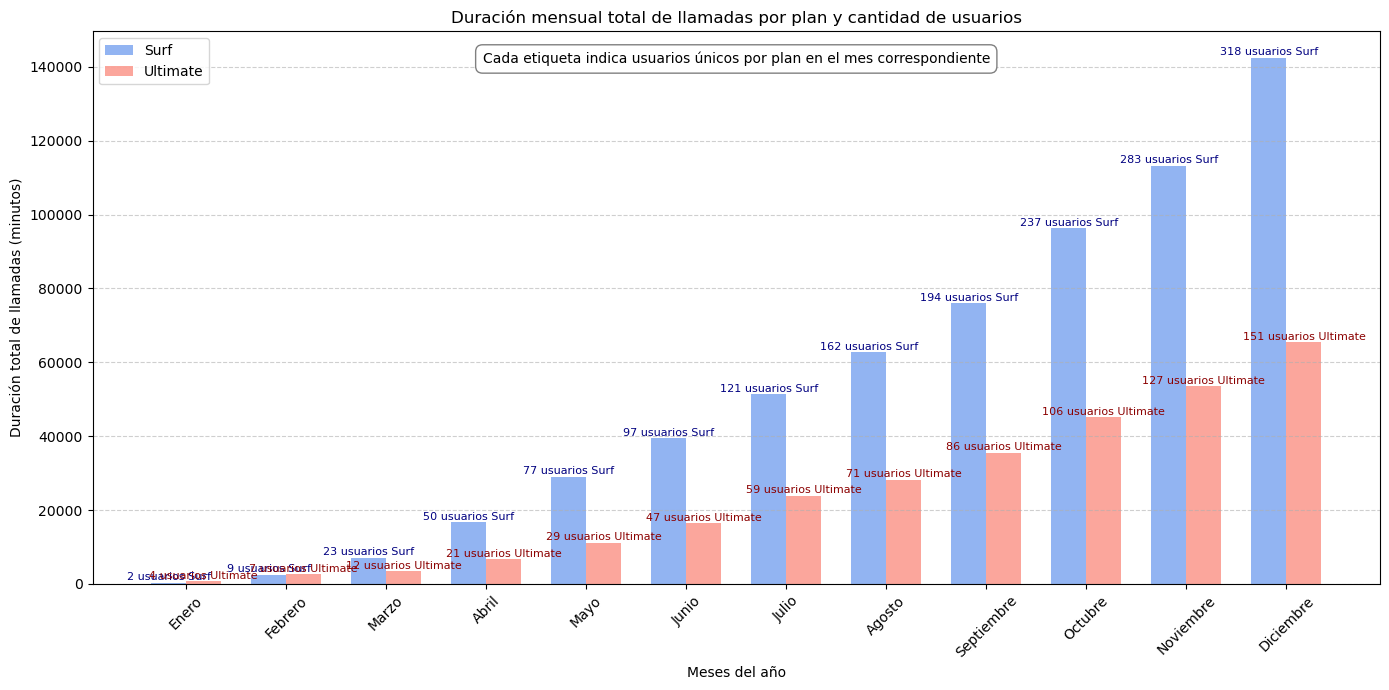

In [52]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
call_total = total.groupby(['period', 'plan'])[
    ['duration']].sum().reset_index()
usuarios_por_plan_mes = total.groupby(['period', 'plan'])[
    'user_id'].nunique().reset_index()
meses = list(range(1, 13))
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
x = list(range(len(meses)))
ancho = 0.35
x_surf = [i - ancho/2 for i in x]
x_ultimate = [i + ancho/2 for i in x]
surf_call = call_total[call_total['plan'] == 'surf'].set_index(
    'period')['duration'].reindex(meses, fill_value=0)
ultimate_call = call_total[call_total['plan'] == 'ultimate'].set_index(
    'period')['duration'].reindex(meses, fill_value=0)
surf_users = usuarios_por_plan_mes[usuarios_por_plan_mes['plan'] == 'surf'].set_index(
    'period')['user_id'].reindex(meses, fill_value=0)
ultimate_users = usuarios_por_plan_mes[usuarios_por_plan_mes['plan'] == 'ultimate'].set_index(
    'period')['user_id'].reindex(meses, fill_value=0)
plt.figure(figsize=(14, 7))
bars_surf = plt.bar(x_surf, surf_call, ancho, label='Surf',
                    alpha=0.7, color='cornflowerblue')
bars_ultimate = plt.bar(x_ultimate, ultimate_call, ancho,
                        label='Ultimate', alpha=0.7, color='salmon')
for i, (bar_s, bar_u) in enumerate(zip(bars_surf, bars_ultimate)):
    plt.text(bar_s.get_x() + bar_s.get_width()/2, bar_s.get_height() + 100,
             f'{surf_users.iloc[i]} usuarios Surf', ha='center', va='bottom', fontsize=8, color='navy')
    plt.text(bar_u.get_x() + bar_u.get_width()/2, bar_u.get_height() + 100,
             f'{ultimate_users.iloc[i]} usuarios Ultimate', ha='center', va='bottom', fontsize=8, color='darkred')
plt.text(0.5, 0.95,
         'Cada etiqueta indica usuarios únicos por plan en el mes correspondiente',
         ha='center', va='center',
         transform=plt.gca().transAxes,
         fontsize=10,
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'))

plt.xlabel('Meses del año')
plt.ylabel('Duración total de llamadas (minutos)')
plt.title('Duración mensual total de llamadas por plan y cantidad de usuarios')
plt.xticks(x, nombres_meses, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

En esta grafica podemos ver que la mawyoria de los usuarios surf son los que mas tiempo pasan en llamada, lo cual es extraño porque el limite que otorga este plan es bajo, esto levanta una pregunta la cual es porque los usuarios prefieren excederse de los limites del surf en lugar de contratar el ultimate.

ademas de que se puede ver una creciente cantidad de usuarios a lo largo de los meses, por lo que se puede deducir que la popularidad de la empreza esta bien.

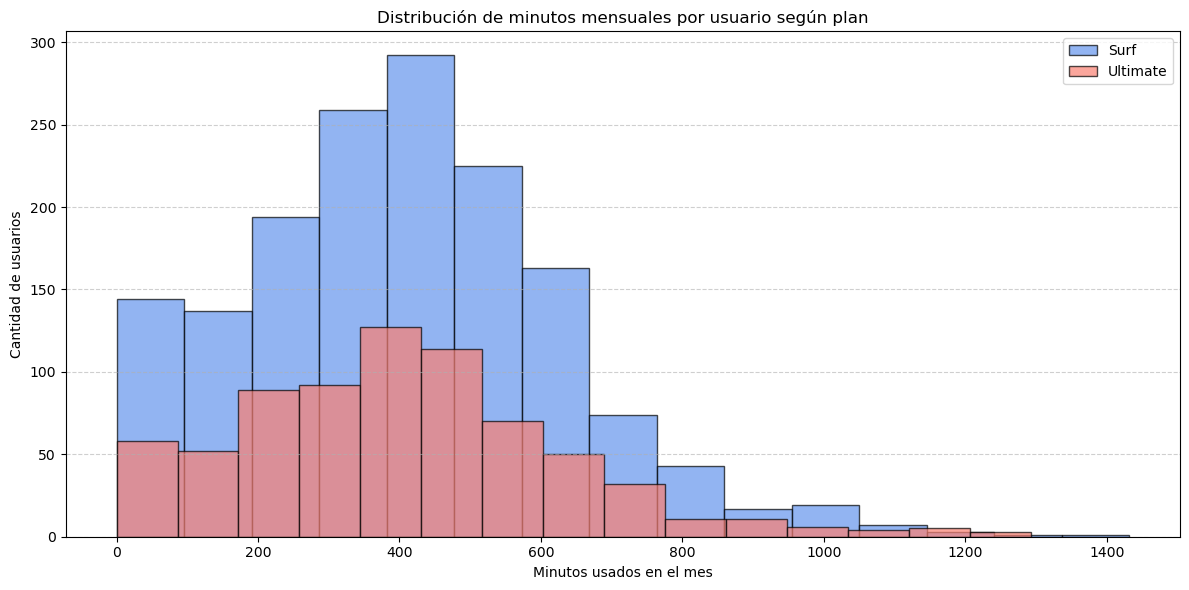

In [53]:

# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
duracion_por_usuario = total.groupby(['user_id', 'period', 'plan'])[
    'duration'].sum().reset_index()
surf_duracion = duracion_por_usuario[duracion_por_usuario['plan']
                                     == 'surf']['duration']
ultimate_duracion = duracion_por_usuario[duracion_por_usuario['plan']
                                         == 'ultimate']['duration']
plt.figure(figsize=(12, 6))
plt.hist(surf_duracion, bins=15, alpha=0.7, label='Surf',
         color='cornflowerblue', edgecolor='black')
plt.hist(ultimate_duracion, bins=15, alpha=0.7,
         label='Ultimate', color='salmon', edgecolor='black')

plt.title('Distribución de minutos mensuales por usuario según plan')
plt.xlabel('Minutos usados en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

y con esta grafica se puede remarcar que el plan surf parece que tiene preferencia por parte de los usuarios demostrado por la candidad de usuarios usando este sistema tambien remarcando los promedios de duracion de las llamadas que es muy superior a lo consumido por los usuarios de ultimate, lo cual a simple vista quiere decir que hay algun problema con los precios, ya que ultimate ofrece una mayor cantidad de minutos para usar y sin embargo es superado por surf por mucho

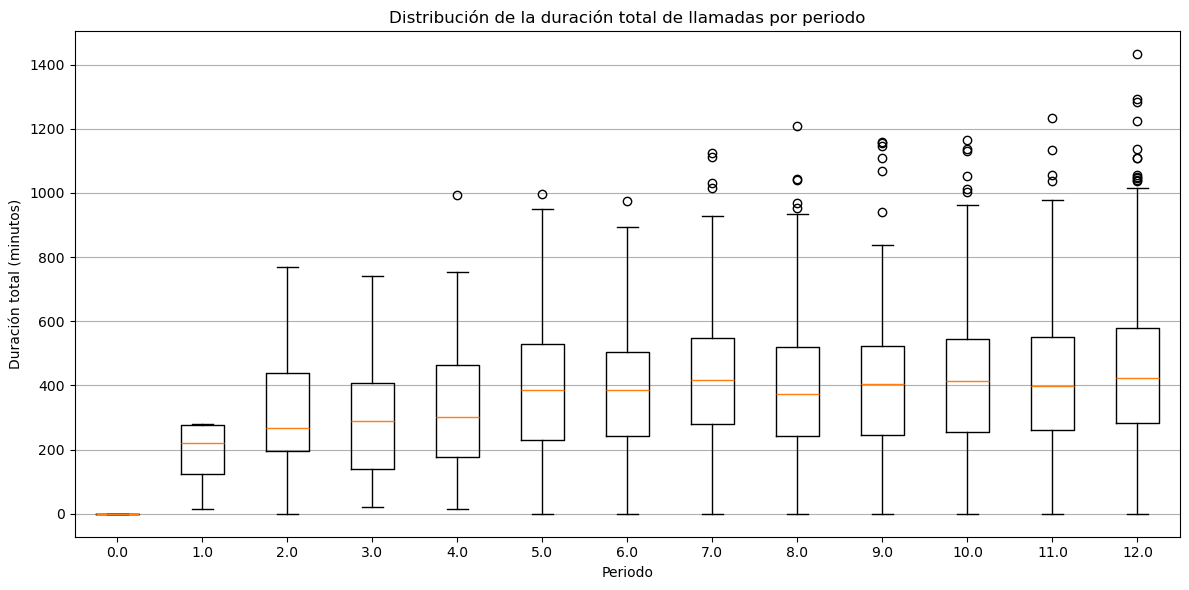

In [54]:
monthly_duration = (
    total
    .groupby(['period', 'user_id'])['duration']
    .sum()
    .reset_index()
)

# Crear datos para el boxplot por periodo
periods = sorted(monthly_duration['period'].unique())

data_by_period = [
    monthly_duration.loc[
        monthly_duration['period'] == p, 'duration'
    ]
    for p in periods
]

plt.figure(figsize=(12, 6))

plt.boxplot(data_by_period)

plt.title('Distribución de la duración total de llamadas por periodo')
plt.xlabel('Periodo')
plt.ylabel('Duración total (minutos)')

plt.xticks(range(1, len(periods) + 1), periods)

plt.grid(axis='y')

plt.tight_layout()
plt.show()

En esta grafica se observa un incremento progresivo en el consumo de minutos a lo largo de los periodos, reflejado en el aumento de la mediana y la dispersión de los datos. Esto indica que, con el tiempo, los usuarios tienden a utilizar más el servicio.

Asimismo, se identifican valores atípicos que representan usuarios con un consumo considerablemente alto.\
Sin embargo, los valores máximos observados (alrededor de 1480 minutos) se mantienen por debajo del límite del plan Ultimate (3000 minutos), lo que indica que incluso los usuarios más intensivos no alcanzan el consumo máximo permitido.

Las cajas muestran el rango donde se concentra la mayor parte del consumo evidenciando que el comportamiento de los usuarios se vuelve más variable conforme avanzan los periodos manteniendo una mediana del consumo en los periodos más avanzados que se sitúa alrededor de los 400 minutos, valor cercano al límite incluido en el plan Surf, lo que sugiere que una parte importante de los usuarios se mantiene dentro de este rango de consumo.

## conclusiones:
En el apartado de telefonia se puede ver que el plan ultimate esta ofreciendo mas de lo que el usuario realmente necesita, quitandole mucho atractivo y haciendo que los clientes se inclinen mas por el plan surf

# Mensajes(NO SIRVE las variable no se pueden medir de la misma manera que las llamadas de aqui hasta la seccion de ingresos)

2. Análisis de mensajes (SMS)

Hoy suele ser el servicio menos utilizado, pero sigue siendo importante.

Preguntas clave
¿Cuántos SMS envían los usuarios?
¿Qué porcentaje no utiliza SMS?
¿Algún plan incentiva más su uso?
Métricas útiles
SMS por usuario al mes.
Promedio de SMS por plan.
Usuarios sin actividad SMS.
Visualizaciones
Histograma de SMS.
Boxplot por plan.
Barras comparando promedios.
Hallazgos comunes

Frecuentemente encontrarás una distribución muy sesgada:

Muchos usuarios envían pocos mensajes.
Un pequeño grupo envía muchísimos.

¿Que grupo manda mas mensajes?\
¿que tanta es la variacion de mensajes entre ultimate y surf?\
¿cuantos usuarios casi no andan mensajes y a que plan pertenecen?\
¿alguna ciudad en especifico tiende a mandar mas o menos mensajes?\
¿cual es el promedio de mensajes enviados por cada plan en cada periodo?


In [55]:
mensajes_enviados=meg_msm.groupby(['user_id','period']).size().reset_index()
mensajes_enviados['plan']=mensajes_enviados['user_id'].map(meg_users.set_index('user_id')['plan'])
mensajes_enviados=mensajes_enviados.rename(columns={0:'n_msm'})
mensajes_enviados


,user_id,period,n_msm,plan
0,1000,12,11,ultimate
1,1001,8,30,surf
2,1001,9,44,surf
3,1001,10,53,surf
4,1001,11,36,surf
...,...,...,...,...
1801,1496,9,21,surf
1802,1496,10,18,surf
1803,1496,11,13,surf
1804,1496,12,11,surf


In [ ]:
mensajes_enviados=

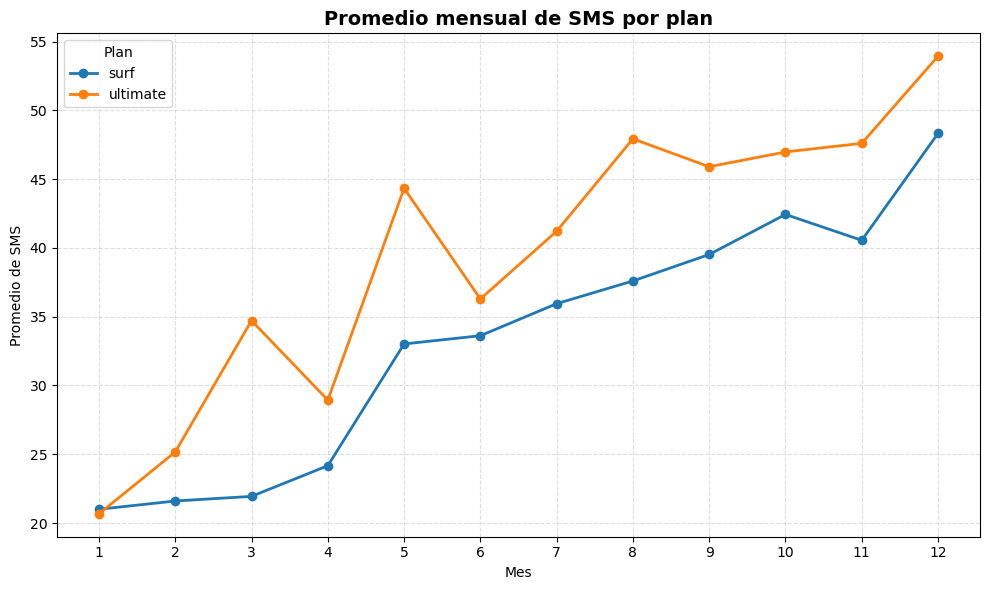

In [75]:
mensajes_mes = (
    mensajes_enviados
    .groupby(['period','plan'])['n_msm']
    .mean()
    .reset_index()
)
plt.figure(figsize=(10, 6))

# Graficar líneas por plan
planes = mensajes_mes['plan'].unique()

for plan in planes:
    datos = mensajes_mes[mensajes_mes['plan'] == plan]

    plt.plot(
        datos['period'],
        datos['n_msm'],
        label=plan,
        marker='o',
        linewidth=2
    )

# Decoración
plt.title('Promedio mensual de SMS por plan', fontsize=14, weight='bold')
plt.xlabel('Mes')
plt.ylabel('Promedio de SMS')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Plan')
plt.xticks(range(1, 13))
plt.tight_layout()

plt.show()

aqui nos podemos dar cuenta de si bien los mensajes de surf son mas, el promedio de mensajes mandados por ambos grupos se ve al reves y esto resulta a que los usuarios de ultimate resultan ser un grupo de consumidores mas estables, por lo mismo que son menos sus p

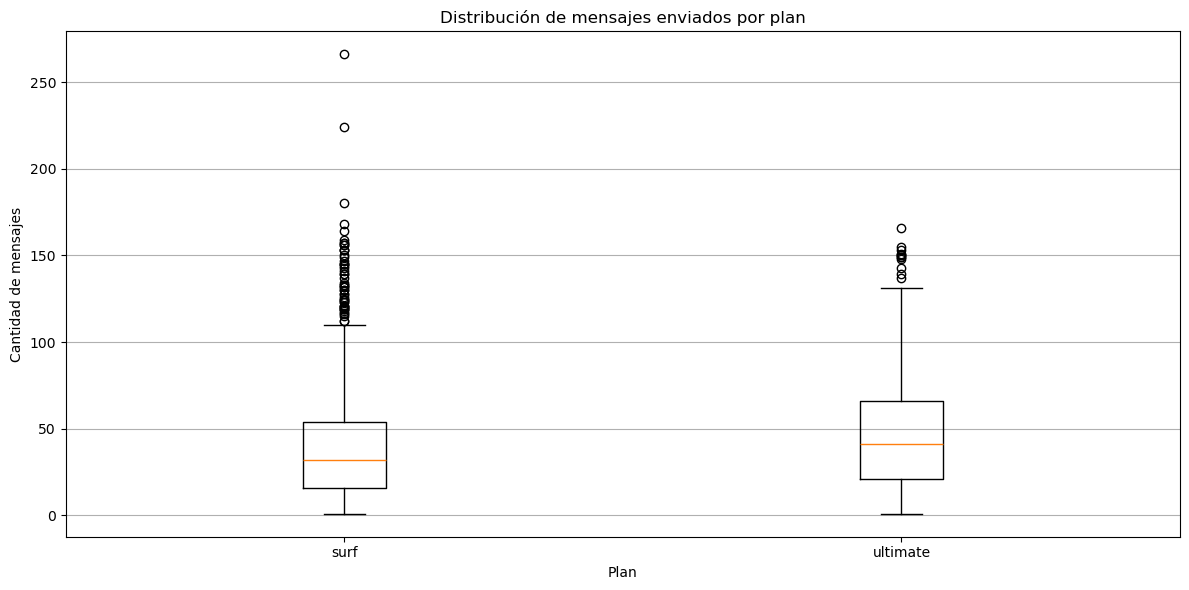

In [81]:
planes = ['surf', 'ultimate']

data_by_plan = [
    mensajes_enviados.loc[
        mensajes_enviados['plan'] == plan,
        'n_msm'
    ]
    for plan in planes
]

plt.figure(figsize=(12, 6))

plt.boxplot(data_by_plan)

plt.title('Distribución de mensajes enviados por plan')
plt.xlabel('Plan')
plt.ylabel('Cantidad de mensajes')

plt.xticks(range(1, len(planes) + 1), planes)

plt.grid(axis='y')

plt.tight_layout()
plt.show()

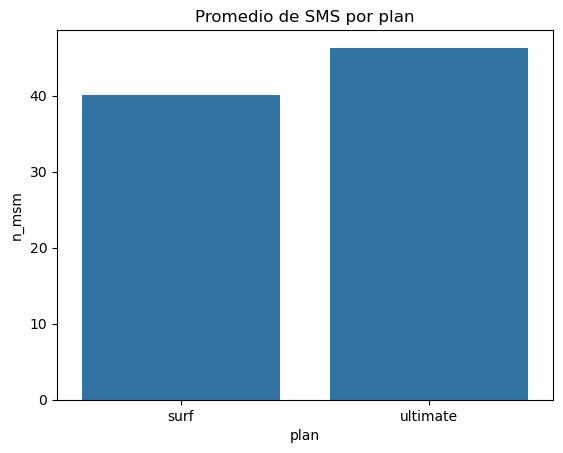

In [67]:
promedio_sms = (
    mensajes_enviados
    .groupby('plan')['n_msm']
    .mean()
    .reset_index()
)

sns.barplot(data=promedio_sms,
            x='plan',
            y='n_msm')

plt.title('Promedio de SMS por plan')
plt.show()

¿que no se supone que surf deberia de generar mas ganancias?

# Internet

3. Análisis de Internet

Normalmente es la variable más importante actualmente.

Preguntas clave
¿Cuántos GB consume cada usuario?
¿Quiénes exceden los límites del plan?
¿Cómo cambia el consumo a lo largo del tiempo?
Métricas útiles
GB consumidos por usuario.
Promedio y mediana.
Percentiles (25, 50, 75, 90).
Visualizaciones
Histograma de GB.
Boxplot por plan.
Evolución mensual.

# Ingresos

Recopilando toda la información anterior, podremos empezar a sacar conclusiones

In [57]:
# En que ciudad es donde se registran mas usuarios y en que fecha del año
ingreso = meg_users.groupby(['month_reg', 'plan'])[
    'user_id'].count().reset_index(name='count')
ingreso.sort_values(by='count', ascending=False, inplace=True)
city = meg_users.groupby('city')['user_id'].count().reset_index(name='count')
city.sort_values(by='count', ascending=False, inplace=True)
city

,city,count
43,"New York-Newark-Jersey City, NY-NJ-PA MSA",80
34,"Los Angeles-Long Beach-Anaheim, CA MSA",29
20,"Dallas-Fort Worth-Arlington, TX MSA",21
14,"Chicago-Naperville-Elgin, IL-IN-WI MSA",19
49,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",17
...,...,...
66,"Stockton, CA MSA",1
27,"Greensboro-High Point, NC MSA",1
24,"El Paso, TX MSA",1
11,"Cape Coral-Fort Myers, FL MSA",1


In [58]:
# en que plan se registran mas usuarios
trafic1 = total.groupby('user_id')['plan'].unique()
trafic = total.groupby(['period', 'plan'])[
    'user_id'].count().unstack(fill_value=0)
trafic_s = trafic['surf'].sum()
trafic_u = trafic['ultimate'].sum()
print(f'''Cantidad de usuarios que usan el plan Surf: {trafic_s}
Cantidad de usuarios que usan el plan Ultimate: {trafic_u}''')

Cantidad de usuarios que usan el plan Surf: 1579
Cantidad de usuarios que usan el plan Ultimate: 724


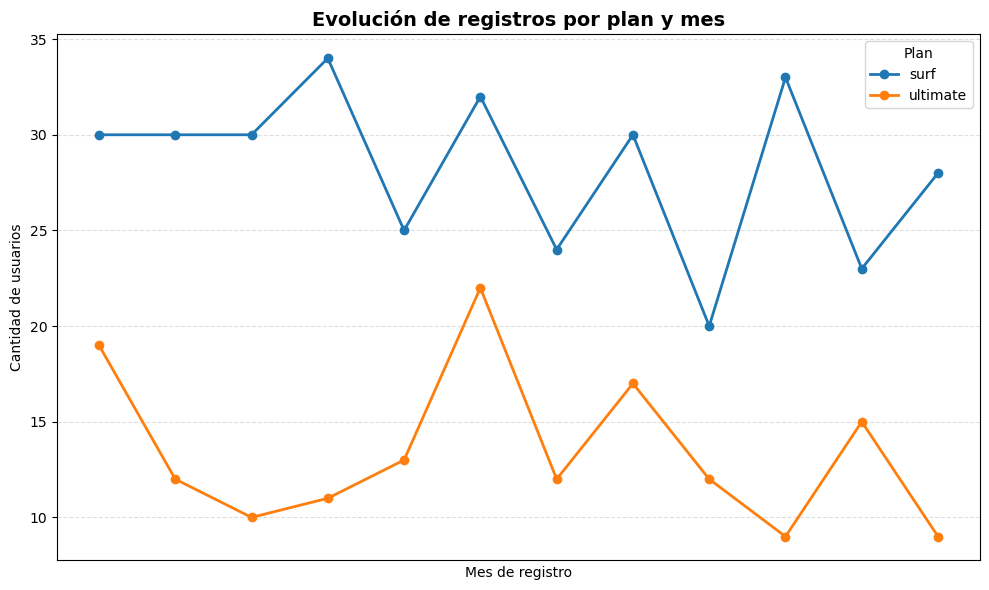

In [59]:
ingreso['month_reg'] = pd.to_datetime(ingreso['month_reg'])
ingreso.sort_values(by='month_reg', inplace=True)

# Crear figura
plt.figure(figsize=(10, 6))

# Graficar líneas por plan
planes = ingreso['plan'].unique()
for plan in planes:
    datos = ingreso[ingreso['plan'] == plan]
    plt.plot(datos['month_reg'], datos['count'],
             label=plan, marker='o', linewidth=2)

# Decoración
plt.title('Evolución de registros por plan y mes', fontsize=14, weight='bold')
plt.xlabel('Mes de registro')
plt.ylabel('Cantidad de usuarios')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Plan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

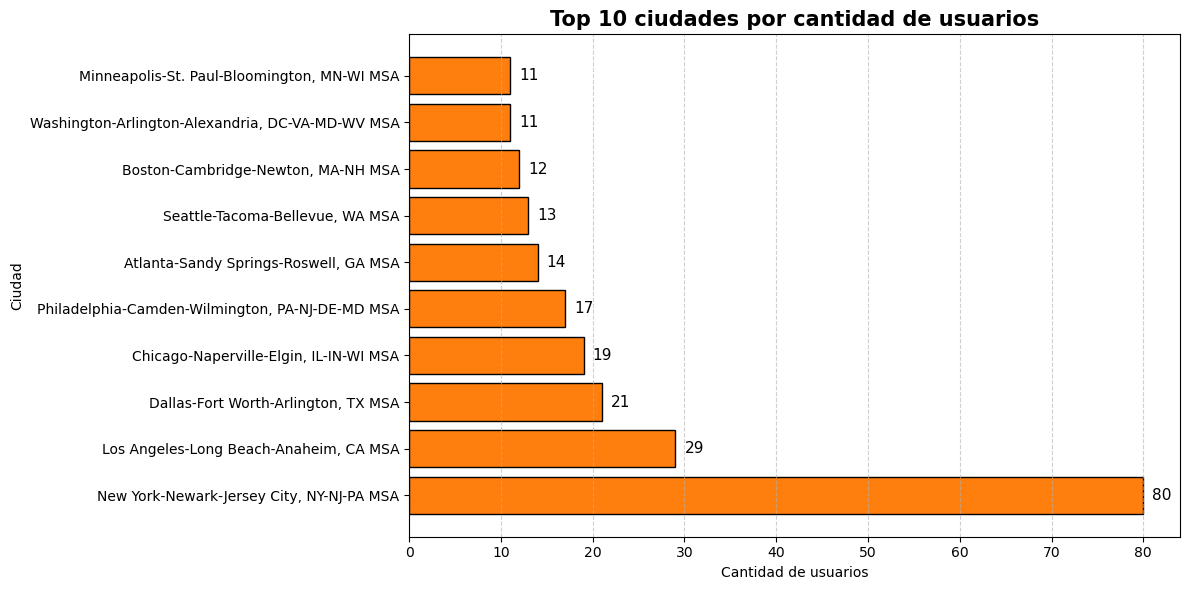

In [60]:
top_city = city.head(10)
plt.figure(figsize=(12, 6))
bars = plt.barh(top_city['city'], top_city['count'],
                color='#ff7f0e', edgecolor='black')
plt.title('Top 10 ciudades por cantidad de usuarios',
          fontsize=15, weight='bold')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Ciudad')
plt.grid(axis='x', linestyle='--', alpha=0.6)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1,
             bar.get_y() + bar.get_height()/2,
             str(int(width)),
             va='center', ha='left', fontsize=11, color='black')

plt.tight_layout()
plt.show()

In [61]:
# confirmando que ciudad genera mas ganancias
total_s = total[total['plan'] == 'surf']['ingreso_mensual'].sum()
total_u = total[total['plan'] == 'ultimate']['ingreso_mensual'].sum()
print(f'surf: {total_s}, ultimate: {total_u}')

surf: 95022.04000000001, ultimate: 52346.0


# Pruebas de hipotesis estadisticas

In [62]:
ganancias_u = total[total['plan'] == 'ultimate']['ingreso_mensual']
ganancias_s = total[total['plan'] != 'ultimate']['ingreso_mensual']
alpha = 0.05
t_stat, p_value = st.ttest_ind(ganancias_s, ganancias_u, equal_var=False)
print('''Hipótesis nula: Hay una diferencia entre los ingresos del plan Surf y del plan Ultimate
''')
if p_value < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')

Hipótesis nula: Hay una diferencia entre los ingresos del plan Surf y del plan Ultimate

Se rechaza la hipótesis nula


In [63]:
# NY_NJ genera más ganancias que el resto de las ciudades:
ganancias_nj = total[total['city'] ==
                     'New York-Newark-Jersey City, NY-NJ-PA MSA']['ingreso_mensual'].sum()
ganancias_ciudad = total.groupby('city')['ingreso_mensual'].sum().reset_index()
result = st.ttest_1samp(ganancias_ciudad['ingreso_mensual'], ganancias_nj)
print('Hipótesis nula: La ciudad de New York genera más ganancias que el resto de las ciudades')
if result.pvalue < alpha:
    print('No se rechaza la hipótesis nula')
else:
    print('Se rechaza la hipótesis nula: se generan más ganancias en otra ciudad')

Hipótesis nula: La ciudad de New York genera más ganancias que el resto de las ciudades
No se rechaza la hipótesis nula


El ingreso promedio de los usuarios de NY-NJ es distinto al de los usuarios de otras regiones

In [64]:
# Prueba las hipótesis
promedio = total_extra.groupby(
    'user_id')['ingreso_mensual'].mean().reset_index()
promedio = pd.merge(
    promedio, meg_users[['user_id', 'city']], on='user_id', how='outer')
media_ciudades = promedio.groupby(
    'city')['ingreso_mensual'].mean().reset_index()
ny_nj = media_ciudades[media_ciudades['city'] ==
                       'New York-Newark-Jersey City, NY-NJ-PA MSA']
media_ciudades = media_ciudades[media_ciudades['city'] !=
                                'New York-Newark-Jersey City, NY-NJ-PA MSA']
print('Hipótesis nula: Los ingresos promedio del área de NY-NJ es diferente al de los usuarios de otras regiones')
alpha = 0.05
ny_nj_valor = ny_nj['ingreso_mensual'].values[0]
results = st.ttest_1samp(media_ciudades['ingreso_mensual'], ny_nj_valor,)

if (results.pvalue/2 < alpha):
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')

Hipótesis nula: Los ingresos promedio del área de NY-NJ es diferente al de los usuarios de otras regiones
No se rechaza la hipótesis nula


Con esto confirmamos que los ingresos de esta región son superiores

¿El plan Surf genera más ganancias que el plan Ultimate?

In [65]:
ganancias_s = total[total['plan'] == 'ultimate']['ingreso_mensual']
ganancias_u = total[total['plan'] != 'ultimate']['ingreso_mensual']
t_stat, p_value_1 = st.ttest_ind(ganancias_s, ganancias_u, equal_var=False)
alpha = 0.05
ganancias_s
if t_stat > 0:
    pruebat = p_value_1/2
else:
    pruebat = 1-(p_value_1/2)
print('''Hipótesis nula: Surf genera más ganancias que Ultimate''')
print(f'Valor p: {pruebat}')
if pruebat < alpha:
    print('No se rechaza la hipótesis nula: Surf genera más ganancias')
else:
    print('Se rechaza la hipótesis nula: Ultimate genera más ganancias que Surf')

Hipótesis nula: Surf genera más ganancias que Ultimate
Valor p: 6.756531989073508e-17
No se rechaza la hipótesis nula: Surf genera más ganancias


Con esta prueba de hipótesis nos damos cuenta de que los clientes pagan menos al exceder los límites del plan Surf que al pagar el plan Ultimate, que ofrece más límite

# porque los usuarios prefieren mas el plan surf? #

sacar las ganancias de los usuarios ultimate y surf y compararlas osea restar cada fila de ambas y de los resultados sacar el promedio de ahorro 

## Conclusión general
A lo largo del análisis se puede ver que el servicio de telefonía ha aumentado su nivel de usuarios con respecto al inicio del año y muy pocos usuarios se han ido, hay una buena retención de audiencia.
La mayor cantidad de audiencia está en Nueva York, por lo que ahí es posible que se encuentre su sede principal. Sin embargo, el hecho de que haya muy poca gente en otras ciudades es algo preocupante, eso quiere decir que se le tiene que destinar más presupuesto a la publicidad, porque la cantidad de ciudades que abarca es algo grande para la cantidad de usuarios que tienen.
También se puede ver que el fuerte de la empresa es en el plan Surf, puesto que genera casi el doble de ganancias que Ultimate. Aquí se le puede bajar de precio a Ultimate, y esto atraería más gente y por ende mejores ganancias.